In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import numpy as np
from sklearn.preprocessing import StandardScaler
import pickle
from xgboost import XGBRegressor

In [2]:

#for dataset Housing.csv

#house_data=pd.read_csv('Housing.csv')
#y=house_data["price"]
#X=house_data.drop(columns=["price","id","date","condition"])
#print(X.shape)

In [3]:
# for  dataset insurance.csv

   #for dataset insurance

insurance_data=pd.read_csv("insurance.csv")
y=insurance_data["charges"]
X=insurance_data.drop(columns=["charges"])
X.dtypes
variable=['sex','smoker','region']
X=pd.get_dummies(data=X,prefix=variable,columns=variable)


In [6]:
scaler=StandardScaler()

x_train,x_val,y_train,y_val=train_test_split(X,y,test_size=0.4,random_state=55)
x_train=scaler.fit_transform(x_train)
x_val=scaler.fit_transform(x_val)


In [7]:
r2_train=[]
r2_val=[]
n_estimator_list=[50,100,200,300,500]
for n_estimator in n_estimator_list:
    model=XGBRegressor(n_estimator=n_estimator,random_state=1234).fit(x_train,y_train)
    y_train_predict=model.predict(x_train)
    y_val_predict=model.predict(x_val)
    acc_train=r2_score(y_train,y_train_predict)
    acc_val=r2_score(y_val,y_val_predict)
    r2_train.append(acc_train)
    r2_val.append(acc_val)


/opt/anaconda3/envs/dl_env/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [13:08:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/dl_env/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [13:08:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/dl_env/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [13:08:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/dl_env/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [13:08:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimator" } are not used.

  bst.up

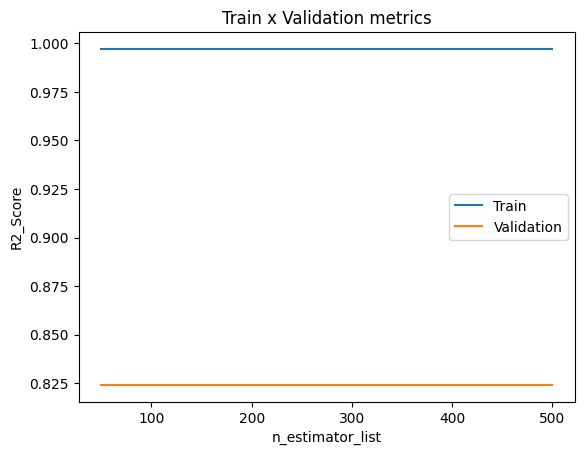

In [8]:
plt.plot(n_estimator_list,r2_train)
plt.plot(n_estimator_list,r2_val)
plt.ylabel('R2_Score')
plt.xlabel('n_estimator_list')
plt.title('Train x Validation metrics')
plt.legend(['Train','Validation'])

In [9]:
index=np.argmax(r2_val)
n_estimator=n_estimator_list[index]
n_estimator

50

In [10]:
r2_train=[]
r2_val=[]
max_depth_list = [2, 3, 4, 5, 6, 8, 10]
for max_depth in max_depth_list:
    model=XGBRegressor(n_estimator=n_estimator,max_depth=max_depth,random_state=1234).fit(x_train,y_train)
    y_train_predict=model.predict(x_train)
    y_val_predict=model.predict(x_val)
    acc_train=r2_score(y_train,y_train_predict)
    acc_val=r2_score(y_val,y_val_predict)
    r2_train.append(acc_train)
    r2_val.append(acc_val)


/opt/anaconda3/envs/dl_env/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [13:08:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/dl_env/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [13:08:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/dl_env/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [13:08:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/dl_env/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [13:08:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimator" } are not used.

  bst.up

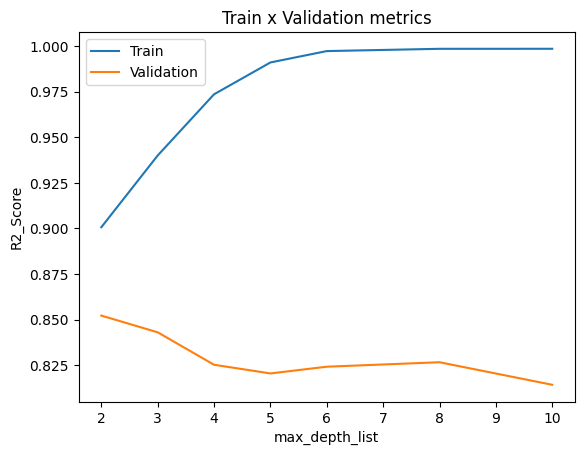

In [11]:
plt.plot(max_depth_list,r2_train)
plt.plot(max_depth_list,r2_val)
plt.ylabel('R2_Score')
plt.xlabel('max_depth_list')
plt.title('Train x Validation metrics')
plt.legend(['Train','Validation'])

In [12]:
index=np.argmax(r2_val)
max_depth=max_depth_list[index]
max_depth

2

In [13]:
r2_train=[]
r2_val=[]
learning_rate_list = [0.001,0.005,0.01,0.03, 0.05, 0.1, 0.2, 0.3]
for learning_rate in learning_rate_list:
    model=XGBRegressor(n_estimator=n_estimator,max_depth=max_depth,learning_rate=learning_rate,random_state=1234).fit(x_train,y_train)
    y_train_predict=model.predict(x_train)
    y_val_predict=model.predict(x_val)
    acc_train=r2_score(y_train,y_train_predict)
    acc_val=r2_score(y_val,y_val_predict)
    r2_train.append(acc_train)
    r2_val.append(acc_val)


/opt/anaconda3/envs/dl_env/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [13:08:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/dl_env/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [13:08:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/dl_env/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [13:08:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/dl_env/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [13:08:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimator" } are not used.

  bst.up

[0.15182764507692825,
 0.5302697851972415,
 0.7268521608007379,
 0.8490239529988659,
 0.8579251565359632,
 0.8571154063973034,
 0.8561879001535815,
 0.8521988005429618]

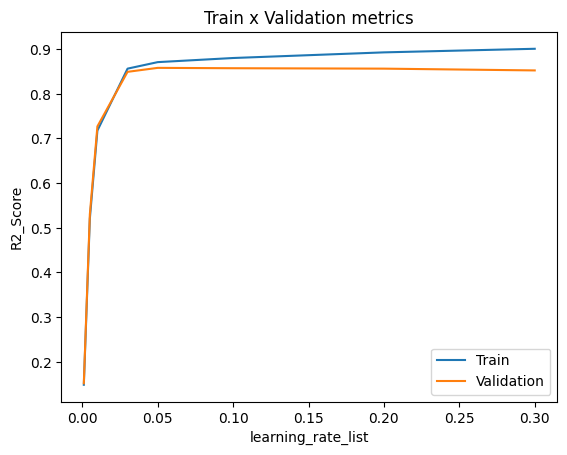

In [14]:
plt.plot(learning_rate_list,r2_train)
plt.plot(learning_rate_list,r2_val)
plt.ylabel('R2_Score')
plt.xlabel('learning_rate_list')
plt.title('Train x Validation metrics')
plt.legend(['Train','Validation'])
r2_val

In [15]:
index=np.argmax(r2_val)
learning_rate=learning_rate_list[index]
learning_rate

0.05

In [16]:
model=XGBRegressor(learning_rate=learning_rate,n_estimators=n_estimator,max_depth=max_depth,verbosity=1,random_state=55).fit(x_train,y_train)
pickle.dump(model,open("Insurance_XGBRegressor.pkl","wb"))


In [39]:
y_train_cap=model.predict(x_train)
r2 = r2_score(y_train, y_train_cap)
r2

0.8707693802576899